In [1]:
# ============================================
# Antencoder v4
# 0. Environment Check
# ============================================

import sys
import platform
import torch

print("Python :", sys.version)
print("Platform:", platform.platform())
print("PyTorch :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cpu")
print("Device:", device)


Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch : 2.11.0+cpu
CUDA available: False
Device: cpu


In [2]:
# ============================================
# 1. Install dependencies
# ============================================

!pip install -q transformers accelerate sentencepiece einops


In [3]:
# ============================================
# 2. Basic imports
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel

print("Basic imports: OK")


Basic imports: OK


In [4]:
# ============================================
# 3. Install MobileCLIP
# ============================================

!git clone -q https://github.com/apple/ml-mobileclip.git
%cd ml-mobileclip
!pip install -q .
%cd ..


/content/ml-mobileclip
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.8 MB/s eta 0:00:00
/content


In [5]:
# ============================================
# 4. Import MobileCLIP
# ============================================

import mobileclip

print("MobileCLIP import: OK")


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


MobileCLIP import: OK


In [6]:
# ============================================
# 5. Download MobileCLIP-S0 checkpoint
# ============================================

!wget -q https://docs-assets.developer.apple.com/ml-research/datasets/mobileclip/mobileclip_s0.pt \
    -O mobileclip_s0.pt

import os

print("Checkpoint exists:", os.path.exists("mobileclip_s0.pt"))
print("Checkpoint size  :", f"{os.path.getsize('mobileclip_s0.pt') / 1024 / 1024:.1f} MB")


Checkpoint exists: True
Checkpoint size  : 205.9 MB


In [7]:
# ============================================
# 6. Load MobileCLIP-S0
# ============================================

import mobileclip
import torch

model, _, preprocess = mobileclip.create_model_and_transforms(
    'mobileclip_s0',
    pretrained='mobileclip_s0.pt'
)

model = model.to("cpu")
model.eval()

print("MobileCLIP-S0: loaded")
print("Device:", next(model.parameters()).device)


MobileCLIP-S0: loaded
Device: cpu


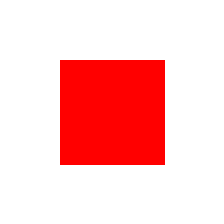

In [8]:
# ============================================
# 7. Dummy image
# ============================================

from PIL import Image, ImageDraw

img = Image.new("RGB", (224, 224), "white")
draw = ImageDraw.Draw(img)

# 赤い四角形を描く
draw.rectangle((60, 60, 164, 164), fill="red")

display(img)


In [9]:
# ============================================
# 8. MobileCLIP image embedding
# ============================================

with torch.no_grad():
    image_tensor = preprocess(img).unsqueeze(0).to("cpu")
    image_features = model.encode_image(image_tensor)

print("Input shape :", image_tensor.shape)
print("Output shape:", image_features.shape)
print("Output dtype:", image_features.dtype)
print("Norm        :", image_features.norm(dim=-1))


Input shape : torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 512])
Output dtype: torch.float32
Norm        : tensor([1.0977])


In [10]:
# ============================================
# 9. Object Teacher
# ============================================

class ObjectTeacher:
    """
    v4 Object Teacher

    Object crop
        ↓
    MobileCLIP image encoder
        ↓
    y_T
    """

    def __init__(self, model, preprocess, device="cpu"):
        self.model = model
        self.preprocess = preprocess
        self.device = device

        self.model.to(self.device)
        self.model.eval()

    @torch.no_grad()
    def encode(self, image):
        """
        image: PIL.Image

        returns:
            y_T: [1, D]
        """
        image_tensor = self.preprocess(image).unsqueeze(0)
        image_tensor = image_tensor.to(self.device)

        y_T = self.model.encode_image(image_tensor)

        return y_T


object_teacher = ObjectTeacher(
    model=model,
    preprocess=preprocess,
    device="cpu"
)

print("Object Teacher: initialized")


Object Teacher: initialized


In [11]:
# ============================================
# 10. Generate y_T
# ============================================

y_T = object_teacher.encode(img)

print("y_T shape :", y_T.shape)
print("y_T dtype :", y_T.dtype)
print("y_T norm  :", y_T.norm(dim=-1))


y_T shape : torch.Size([1, 512])
y_T dtype : torch.float32
y_T norm  : tensor([1.0977])


In [12]:
# ============================================
# 11. Action Encoder
# ============================================

import torch
import torch.nn as nn


class ActionEncoder(nn.Module):
    """
    v4 Action Encoder

    Input:
        action trajectory [B, T, action_dim]

    Output:
        z_T [B, latent_dim]
    """

    def __init__(
        self,
        action_dim,
        hidden_dim=128,
        latent_dim=128,
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, action):
        """
        action: [B, T, action_dim]
        """

        # Encode each timestep
        h = self.encoder(action)

        # Temporal aggregation
        z_T = h.mean(dim=1)

        return z_T


In [13]:
# ============================================
# 12. Instantiate Action Encoder
# ============================================

ACTION_DIM = 7
ACTION_HIDDEN_DIM = 128
ACTION_LATENT_DIM = 128

action_encoder = ActionEncoder(
    action_dim=ACTION_DIM,
    hidden_dim=ACTION_HIDDEN_DIM,
    latent_dim=ACTION_LATENT_DIM,
).to("cpu")

print(action_encoder)


ActionEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
)


In [14]:
# ============================================
# 13. Dummy action trajectory
# ============================================

BATCH_SIZE = 2
SEQ_LEN = 20

dummy_action = torch.randn(
    BATCH_SIZE,
    SEQ_LEN,
    ACTION_DIM,
    device="cpu"
)

print("Action shape:", dummy_action.shape)


Action shape: torch.Size([2, 20, 7])


In [15]:
# ============================================
# 14. Action → z_T
# ============================================

with torch.no_grad():
    z_T = action_encoder(dummy_action)

print("z_T shape :", z_T.shape)
print("z_T dtype :", z_T.dtype)
print("z_T device:", z_T.device)


z_T shape : torch.Size([2, 128])
z_T dtype : torch.float32
z_T device: cpu


In [16]:
# ============================================
# 15. MobileCLIP text embedding
# ============================================

tokenizer = mobileclip.get_tokenizer('mobileclip_s0')

texts = [
    "red cup",
    "blue cup",
    "pick up the red cup",
    "place the cup on the table",
]

text_tokens = tokenizer(texts).to("cpu")

with torch.no_grad():
    text_features = model.encode_text(text_tokens)

print("Text tokens shape :", text_tokens.shape)
print("Text features shape:", text_features.shape)
print("Text dtype         :", text_features.dtype)
print("Text norms         :", text_features.norm(dim=-1))


Text tokens shape : torch.Size([4, 77])
Text features shape: torch.Size([4, 512])
Text dtype         : torch.float32
Text norms         : tensor([ 9.7846,  9.7187,  9.6232, 10.7877])


In [17]:
# ============================================
# 16. Reference CLIP
#    Comparison-only Teacher
# ============================================

!pip install -q git+https://github.com/openai/CLIP.git


  Preparing metadata (setup.py) ... done


In [18]:
# ============================================
# 17. Load OpenAI CLIP
# ============================================

import clip
import torch

clip_device = "cpu"

clip_model, clip_preprocess = clip.load(
    "ViT-B/32",
    device=clip_device,
    jit=False
)

clip_model.eval()

print("Reference CLIP: loaded")
print("Device:", next(clip_model.parameters()).device)


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 66.7MiB/s]


Reference CLIP: loaded
Device: cpu


In [19]:
# ============================================
# 18. Compare image embeddings
# ============================================

with torch.no_grad():
    clip_image = clip_preprocess(img).unsqueeze(0).to("cpu")
    clip_y_T = clip_model.encode_image(clip_image)

print("MobileCLIP y_T :", y_T.shape)
print("Reference CLIP :", clip_y_T.shape)

print("MobileCLIP norm:", y_T.norm(dim=-1))
print("CLIP norm      :", clip_y_T.norm(dim=-1))


MobileCLIP y_T : torch.Size([1, 512])
Reference CLIP : torch.Size([1, 512])
MobileCLIP norm: tensor([1.0977])
CLIP norm      : tensor([12.0037])


In [20]:
# ============================================
# 19. Language representation container
# ============================================

from dataclasses import dataclass
from typing import Optional


@dataclass
class LanguageSample:
    """
    L is always preserved as natural language.

    Optional embeddings are comparison baselines.
    """

    text: str

    mobileclip_embedding: Optional[torch.Tensor] = None
    clip_embedding: Optional[torch.Tensor] = None


In [21]:
# ============================================
# 20. Toy language samples
# ============================================

language_samples = [
    LanguageSample("pick up the red cup"),
    LanguageSample("pick up the blue cup"),
    LanguageSample("move the red cup to the table"),
    LanguageSample("place the blue cup on the table"),
]

for sample in language_samples:
    print(sample.text)


pick up the red cup
pick up the blue cup
move the red cup to the table
place the blue cup on the table


In [22]:
# ============================================
# 21. MobileCLIP text baseline
# ============================================

mobileclip_tokenizer = mobileclip.get_tokenizer("mobileclip_s0")

texts = [sample.text for sample in language_samples]

tokens = mobileclip_tokenizer(texts).to("cpu")

with torch.no_grad():
    mobileclip_text_features = model.encode_text(tokens)

print("MobileCLIP(L) shape:", mobileclip_text_features.shape)


MobileCLIP(L) shape: torch.Size([4, 512])


In [23]:
for sample, embedding in zip(
    language_samples,
    mobileclip_text_features
):
    sample.mobileclip_embedding = embedding.detach().cpu()

print("MobileCLIP(L) baseline: stored")


MobileCLIP(L) baseline: stored


In [25]:
# ============================================
# 16. Reference CLIP
# ============================================

!pip install -q git+https://github.com/openai/CLIP.git

import clip
import torch

REFERENCE_CLIP_NAME = "ViT-B/32"

reference_clip, reference_preprocess = clip.load(
    REFERENCE_CLIP_NAME,
    device="cpu",
    jit=False,
)

reference_clip.eval()

print("Reference CLIP:", REFERENCE_CLIP_NAME)
print("Device:", next(reference_clip.parameters()).device)


  Preparing metadata (setup.py) ... done
Reference CLIP: ViT-B/32
Device: cpu


In [26]:
# ============================================
# 22. OpenAI CLIP text baseline
# ============================================

texts = [sample.text for sample in language_samples]

clip_tokens = clip.tokenize(texts).to("cpu")

with torch.no_grad():
    clip_text_features = reference_clip.encode_text(clip_tokens)

print("OpenAI CLIP(L) shape:", clip_text_features.shape)


OpenAI CLIP(L) shape: torch.Size([4, 512])


In [27]:
# ============================================
# 24. Toy Language Vocabulary
# ============================================

SPECIAL_TOKENS = {
    "<PAD>": 0,
    "<UNK>": 1,
}

words = [
    "pick", "up", "the", "red", "blue",
    "cup", "move", "to", "table", "place", "on"
]

vocab = dict(SPECIAL_TOKENS)

for word in words:
    vocab[word] = len(vocab)

idx_to_token = {v: k for k, v in vocab.items()}

print("Vocabulary size:", len(vocab))
print(vocab)


Vocabulary size: 13
{'<PAD>': 0, '<UNK>': 1, 'pick': 2, 'up': 3, 'the': 4, 'red': 5, 'blue': 6, 'cup': 7, 'move': 8, 'to': 9, 'table': 10, 'place': 11, 'on': 12}


In [28]:
# ============================================
# 25. Toy tokenizer
# ============================================

MAX_LENGTH = 8


def tokenize_toy(text, vocab, max_length=MAX_LENGTH):
    tokens = text.lower().split()

    ids = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]

    # Padding
    ids = ids[:max_length]
    ids += [vocab["<PAD>"]] * (max_length - len(ids))

    return torch.tensor(ids, dtype=torch.long)


texts = [sample.text for sample in language_samples]

toy_tokens = torch.stack([
    tokenize_toy(text, vocab)
    for text in texts
])

print("Token shape:", toy_tokens.shape)
print(toy_tokens)


Token shape: torch.Size([4, 8])
tensor([[ 2,  3,  4,  5,  7,  0,  0,  0],
        [ 2,  3,  4,  6,  7,  0,  0,  0],
        [ 8,  4,  5,  7,  9,  4, 10,  0],
        [11,  4,  6,  7, 12,  4, 10,  0]])


In [29]:
# ============================================
# 26. Language Encoder
# ============================================

class LanguageEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        y_dim=128,
        z_dim=128,
        max_length=8,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0,
        )

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=4,
                dim_feedforward=hidden_dim * 2,
                batch_first=True,
            ),
            num_layers=2,
        )

        self.y_head = nn.Linear(embed_dim, y_dim)
        self.z_head = nn.Linear(embed_dim, z_dim)

    def forward(self, tokens):

        # [B, T] → [B, T, D]
        x = self.embedding(tokens)

        # Transformer
        x = self.encoder(x)

        # Mean pooling
        h = x.mean(dim=1)

        # What
        y_L = self.y_head(h)

        # How
        z_L = self.z_head(h)

        return y_L, z_L


In [30]:
# ============================================
# 27. Instantiate Language Encoder
# ============================================

language_encoder = LanguageEncoder(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    y_dim=128,
    z_dim=128,
).to("cpu")

print(language_encoder)


LanguageEncoder(
  (embedding): Embedding(13, 128, padding_idx=0)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (y_head): Linear(in_features=128, out_features=128, bias=True)
  (z_head): Linear(in_features=128, out_features=128, bias=True)
)


In [31]:
# ============================================
# 28. Language → y_L, z_L
# ============================================

language_encoder.eval()

with torch.no_grad():
    y_L, z_L = language_encoder(toy_tokens)

print("y_L shape:", y_L.shape)
print("z_L shape:", z_L.shape)
print("y_L dtype:", y_L.dtype)
print("z_L dtype:", z_L.dtype)


y_L shape: torch.Size([4, 128])
z_L shape: torch.Size([4, 128])
y_L dtype: torch.float32
z_L dtype: torch.float32


In [32]:
# ============================================
# 29. What alignment projection
# ============================================

class WhatAlignmentHead(nn.Module):
    """
    Project frozen MobileCLIP teacher features
    into the Antencoder What latent space.
    """

    def __init__(self, teacher_dim=512, latent_dim=128):
        super().__init__()

        self.projection = nn.Sequential(
            nn.Linear(teacher_dim, latent_dim),
            nn.LayerNorm(latent_dim),
        )

    def forward(self, y_T):
        return self.projection(y_T)


what_alignment = WhatAlignmentHead(
    teacher_dim=512,
    latent_dim=128,
).to("cpu")

print(what_alignment)


WhatAlignmentHead(
  (projection): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
)


In [33]:
# ============================================
# 30. Prepare one aligned sample
# ============================================

# y_T currently has shape [1, 512]
# Expand it to match the toy batch
y_T_batch = y_T.expand(BATCH_SIZE, -1)

with torch.no_grad():
    y_T_projected = what_alignment(y_T_batch)

print("y_T original   :", y_T_batch.shape)
print("y_T projected  :", y_T_projected.shape)
print("z_T            :", z_T.shape)
print("y_L            :", y_L.shape)
print("z_L            :", z_L.shape)


y_T original   : torch.Size([2, 512])
y_T projected  : torch.Size([2, 128])
z_T            : torch.Size([2, 128])
y_L            : torch.Size([4, 128])
z_L            : torch.Size([4, 128])


In [34]:
# ============================================
# 30. Toy (V, A, L) aligned dataset
# ============================================

import torch
from PIL import Image, ImageDraw


def make_object_image(color):
    img = Image.new("RGB", (224, 224), "white")
    draw = ImageDraw.Draw(img)
    draw.rectangle(
        (60, 60, 164, 164),
        fill=color
    )
    return img


toy_samples = [
    {
        "image": make_object_image("red"),
        "action": torch.randn(20, 7),
        "language": "pick up the red cup",
    },
    {
        "image": make_object_image("blue"),
        "action": torch.randn(20, 7),
        "language": "pick up the blue cup",
    },
    {
        "image": make_object_image("red"),
        "action": torch.randn(20, 7),
        "language": "move the red cup to the table",
    },
    {
        "image": make_object_image("blue"),
        "action": torch.randn(20, 7),
        "language": "place the blue cup on the table",
    },
]

print("Number of samples:", len(toy_samples))

for i, sample in enumerate(toy_samples):
    print(
        f"[{i}] "
        f"A={sample['action'].shape}, "
        f"L='{sample['language']}'"
    )


Number of samples: 4
[0] A=torch.Size([20, 7]), L='pick up the red cup'
[1] A=torch.Size([20, 7]), L='pick up the blue cup'
[2] A=torch.Size([20, 7]), L='move the red cup to the table'
[3] A=torch.Size([20, 7]), L='place the blue cup on the table'


In [35]:
# ============================================
# 31. Build aligned batch
# ============================================

toy_images = [x["image"] for x in toy_samples]

toy_actions = torch.stack([
    x["action"]
    for x in toy_samples
])

toy_languages = [
    x["language"]
    for x in toy_samples
]

print("Action batch:", toy_actions.shape)
print("Language batch:", len(toy_languages))


Action batch: torch.Size([4, 20, 7])
Language batch: 4


In [36]:
# ============================================
# 32. Vision Teacher batch
# ============================================

with torch.no_grad():

    vision_inputs = torch.stack([
        preprocess(image)
        for image in toy_images
    ])

    y_T_batch = model.encode_image(
        vision_inputs
    )

print("y_T batch:", y_T_batch.shape)


y_T batch: torch.Size([4, 512])


In [37]:
# ============================================
# 33. Action Teacher batch
# ============================================

with torch.no_grad():
    z_T_batch = action_encoder(
        toy_actions
    )

print("z_T batch:", z_T_batch.shape)


z_T batch: torch.Size([4, 128])


In [38]:
# ============================================
# 34. Language Student batch
# ============================================

language_tokens = torch.stack([
    tokenize_toy(
        text,
        vocab,
        max_length=MAX_LENGTH
    )
    for text in toy_languages
])

with torch.no_grad():
    y_L_batch, z_L_batch = language_encoder(
        language_tokens
    )

print("Language tokens:", language_tokens.shape)
print("y_L batch:", y_L_batch.shape)
print("z_L batch:", z_L_batch.shape)


Language tokens: torch.Size([4, 8])
y_L batch: torch.Size([4, 128])
z_L batch: torch.Size([4, 128])


In [39]:
# ============================================
# 35. Alignment check
# ============================================

print("========================================")
print("Aligned V + A + L batch")
print("========================================")

print("V  → y_T :", y_T_batch.shape)
print("A  → z_T :", z_T_batch.shape)
print("L  → y_L :", y_L_batch.shape)
print("L  → z_L :", z_L_batch.shape)

assert y_T_batch.shape[0] == y_L_batch.shape[0]
assert z_T_batch.shape[0] == z_L_batch.shape[0]

print("Alignment: OK")


Aligned V + A + L batch
V  → y_T : torch.Size([4, 512])
A  → z_T : torch.Size([4, 128])
L  → y_L : torch.Size([4, 128])
L  → z_L : torch.Size([4, 128])
Alignment: OK


In [40]:
# ============================================
# 36. Action Distillation Loss
# ============================================

import torch.nn.functional as F


def action_distillation_loss(z_L, z_T):
    """
    Student: z_L
    Teacher: z_T

    Teacher is detached so gradients do not flow
    into the teacher branch.
    """

    z_T = z_T.detach()

    return F.mse_loss(z_L, z_T)


loss_z = action_distillation_loss(
    z_L_batch,
    z_T_batch,
)

print("L_action_distill:", loss_z.item())


L_action_distill: 0.13808615505695343


In [41]:
# ============================================
# 37. Action cosine similarity
# ============================================

with torch.no_grad():

    z_L_norm = F.normalize(z_L_batch, dim=-1)
    z_T_norm = F.normalize(z_T_batch, dim=-1)

    z_cosine = (
        z_L_norm * z_T_norm
    ).sum(dim=-1)

print("z cosine similarities:", z_cosine)
print("z cosine mean        :", z_cosine.mean().item())


z cosine similarities: tensor([0.1119, 0.0858, 0.0920, 0.1117])
z cosine mean        : 0.1003480851650238


In [42]:
# ============================================
# 38. Project Vision Teacher
# ============================================

y_T_projected = what_alignment(
    y_T_batch.detach()
)

print("y_T projected:", y_T_projected.shape)
print("y_L          :", y_L_batch.shape)


y_T projected: torch.Size([4, 128])
y_L          : torch.Size([4, 128])


In [43]:
# ============================================
# 39. Object Contrastive Loss
# ============================================

def object_contrastive_loss(
    y_L,
    y_T,
    temperature=0.07,
):
    """
    Symmetric InfoNCE.

    Positive pair:
        y_L[i] ↔ y_T[i]

    Negative pairs:
        y_L[i] ↔ y_T[j], i != j
    """

    y_L = F.normalize(y_L, dim=-1)
    y_T = F.normalize(y_T.detach(), dim=-1)

    logits = y_L @ y_T.T
    logits = logits / temperature

    labels = torch.arange(
        y_L.size(0),
        device=y_L.device
    )

    loss_L_to_T = F.cross_entropy(
        logits,
        labels
    )

    loss_T_to_L = F.cross_entropy(
        logits.T,
        labels
    )

    return 0.5 * (
        loss_L_to_T + loss_T_to_L
    )


loss_y = object_contrastive_loss(
    y_L_batch,
    y_T_projected,
)

print("L_object_contrastive:", loss_y.item())


L_object_contrastive: 1.399638295173645


In [44]:
# ============================================
# 40. Alignment losses
# ============================================

print("========================================")
print("Alignment losses")
print("========================================")

print("L_y (object contrastive):", loss_y.item())
print("L_z (action distill)    :", loss_z.item())


Alignment losses
L_y (object contrastive): 1.399638295173645
L_z (action distill)    : 0.13808615505695343


In [45]:
# ============================================
# 41. Mini training setup
# ============================================

language_encoder.train()
what_alignment.train()

optimizer = torch.optim.AdamW(
    list(language_encoder.parameters()) +
    list(what_alignment.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

print("Trainable parameters:",
      sum(
          p.numel()
          for p in language_encoder.parameters()
          if p.requires_grad
      ) +
      sum(
          p.numel()
          for p in what_alignment.parameters()
          if p.requires_grad
      ))


Trainable parameters: 365568


In [46]:
# ============================================
# 42. CPU mini training
# ============================================

NUM_STEPS = 100

history = []

for step in range(NUM_STEPS):

    optimizer.zero_grad()

    # Language branch
    y_L, z_L = language_encoder(
        language_tokens
    )

    # Frozen vision teacher projection
    y_T_projected = what_alignment(
        y_T_batch.detach()
    )

    # Losses
    loss_y = object_contrastive_loss(
        y_L,
        y_T_projected,
    )

    loss_z = action_distillation_loss(
        z_L,
        z_T_batch.detach(),
    )

    # Total alignment loss
    loss = loss_y + loss_z

    loss.backward()
    optimizer.step()

    history.append([
        loss.item(),
        loss_y.item(),
        loss_z.item(),
    ])

    if step % 10 == 0 or step == NUM_STEPS - 1:
        print(
            f"step={step:03d} "
            f"total={loss.item():.4f} "
            f"Ly={loss_y.item():.4f} "
            f"Lz={loss_z.item():.4f}"
        )


step=000 total=1.4544 Ly=1.3239 Lz=0.1304
step=010 total=0.8519 Ly=0.8204 Lz=0.0316
step=020 total=0.7325 Ly=0.7191 Lz=0.0134
step=030 total=0.7174 Ly=0.7103 Lz=0.0072
step=040 total=0.7134 Ly=0.7088 Lz=0.0046
step=050 total=0.7112 Ly=0.7073 Lz=0.0039
step=060 total=0.7103 Ly=0.7066 Lz=0.0037
step=070 total=0.7099 Ly=0.7061 Lz=0.0038
step=080 total=0.7099 Ly=0.7060 Lz=0.0039
step=090 total=0.7079 Ly=0.7051 Lz=0.0029
step=099 total=0.7078 Ly=0.7049 Lz=0.0029


In [47]:
# ============================================
# 43. State Encoder
# ============================================

class StateEncoder(nn.Module):
    """
    Encode robot/environment state into s.

    Input:
        state [B, state_dim]

    Output:
        s [B, state_latent_dim]
    """

    def __init__(
        self,
        state_dim=8,
        hidden_dim=128,
        latent_dim=128,
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, state):
        return self.encoder(state)


In [48]:
# ============================================
# 44. Instantiate State Encoder
# ============================================

STATE_DIM = 8
STATE_LATENT_DIM = 128

state_encoder = StateEncoder(
    state_dim=STATE_DIM,
    hidden_dim=128,
    latent_dim=STATE_LATENT_DIM,
).to("cpu")

print(state_encoder)


StateEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
)


In [49]:
# ============================================
# 45. Toy state batch
# ============================================

toy_states = torch.randn(
    len(toy_samples),
    STATE_DIM,
)

print("State batch:", toy_states.shape)


State batch: torch.Size([4, 8])


In [50]:
# ============================================
# 46. State → s
# ============================================

with torch.no_grad():
    s_batch = state_encoder(toy_states)

print("s shape :", s_batch.shape)
print("s dtype :", s_batch.dtype)
print("s device:", s_batch.device)


s shape : torch.Size([4, 128])
s dtype : torch.float32
s device: cpu


In [51]:
# ============================================
# 47. Antencoder multimodal representation
# ============================================

# y_L is the What representation
# z_L is the How representation
# s is the State representation

multimodal = torch.cat(
    [
        y_L_batch,
        z_L_batch,
        s_batch,
    ],
    dim=-1,
)

print("multimodal shape:", multimodal.shape)


multimodal shape: torch.Size([4, 384])


In [52]:
# ============================================
# 48. Language Decoder
# ============================================

class LanguageDecoder(nn.Module):

    def __init__(
        self,
        latent_dim=384,
        vocab_size=13,
        d_model=128,
        max_length=8,
    ):
        super().__init__()

        self.max_length = max_length

        self.latent_projection = nn.Linear(
            latent_dim,
            d_model,
        )

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=0,
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=256,
            batch_first=True,
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=2,
        )

        self.output_head = nn.Linear(
            d_model,
            vocab_size,
        )

    def forward(
        self,
        latent,
        target_tokens,
    ):

        # latent → memory
        memory = self.latent_projection(
            latent
        ).unsqueeze(1)

        # teacher-forcing input
        token_emb = self.token_embedding(
            target_tokens
        )

        # causal mask
        seq_len = target_tokens.size(1)

        causal_mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                device=target_tokens.device,
                dtype=torch.bool,
            ),
            diagonal=1,
        )

        decoded = self.decoder(
            tgt=token_emb,
            memory=memory,
            tgt_mask=causal_mask,
        )

        logits = self.output_head(
            decoded
        )

        return logits


In [53]:
# ============================================
# 49. Instantiate Language Decoder
# ============================================

language_decoder = LanguageDecoder(
    latent_dim=384,
    vocab_size=len(vocab),
    d_model=128,
    max_length=MAX_LENGTH,
).to("cpu")

print(language_decoder)


LanguageDecoder(
  (latent_projection): Linear(in_features=384, out_features=128, bias=True)
  (token_embedding): Embedding(13, 128, padding_idx=0)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inp

In [54]:
# ============================================
# 50. Decoder forward test
# ============================================

decoder_logits = language_decoder(
    multimodal,
    language_tokens,
)

print("Decoder logits:", decoder_logits.shape)


Decoder logits: torch.Size([4, 8, 13])


In [55]:
# ============================================
# 51. Add BOS / EOS tokens
# ============================================

BOS_TOKEN = "<BOS>"
EOS_TOKEN = "<EOS>"

if BOS_TOKEN not in vocab:
    vocab[BOS_TOKEN] = len(vocab)

if EOS_TOKEN not in vocab:
    vocab[EOS_TOKEN] = len(vocab)

idx_to_token = {
    v: k for k, v in vocab.items()
}

print("Vocabulary size:", len(vocab))
print(vocab)


Vocabulary size: 15
{'<PAD>': 0, '<UNK>': 1, 'pick': 2, 'up': 3, 'the': 4, 'red': 5, 'blue': 6, 'cup': 7, 'move': 8, 'to': 9, 'table': 10, 'place': 11, 'on': 12, '<BOS>': 13, '<EOS>': 14}


In [56]:
MAX_LENGTH = 10
# ============================================
# 52. Autoregressive tokenizer
# ============================================

def tokenize_language(
    text,
    vocab,
    max_length=MAX_LENGTH,
):
    words = text.lower().split()

    ids = [
        vocab[BOS_TOKEN]
    ]

    ids += [
        vocab.get(
            word,
            vocab["<UNK>"]
        )
        for word in words
    ]

    ids.append(
        vocab[EOS_TOKEN]
    )

    ids = ids[:max_length]

    ids += [
        vocab["<PAD>"]
    ] * (max_length - len(ids))

    return torch.tensor(
        ids,
        dtype=torch.long
    )


In [57]:
# ============================================
# 53. Build autoregressive language batch
# ============================================

language_tokens = torch.stack([
    tokenize_language(
        text,
        vocab,
    )
    for text in toy_languages
])

print("Language tokens:", language_tokens.shape)

for i in range(len(toy_languages)):
    print(
        i,
        toy_languages[i],
        "→",
        language_tokens[i].tolist()
    )


Language tokens: torch.Size([4, 10])
0 pick up the red cup → [13, 2, 3, 4, 5, 7, 14, 0, 0, 0]
1 pick up the blue cup → [13, 2, 3, 4, 6, 7, 14, 0, 0, 0]
2 move the red cup to the table → [13, 8, 4, 5, 7, 9, 4, 10, 14, 0]
3 place the blue cup on the table → [13, 11, 4, 6, 7, 12, 4, 10, 14, 0]


In [58]:
# ============================================
# 54. Shifted teacher forcing
# ============================================

decoder_input = language_tokens[:, :-1]

decoder_target = language_tokens[:, 1:]

print("Decoder input :", decoder_input.shape)
print("Decoder target:", decoder_target.shape)


Decoder input : torch.Size([4, 9])
Decoder target: torch.Size([4, 9])


In [59]:
# ============================================
# 55. Language reconstruction forward
# ============================================

language_encoder.eval()
state_encoder.eval()
language_decoder.train()

with torch.no_grad():

    y_L_batch, z_L_batch = language_encoder(
        language_tokens
    )

    s_batch = state_encoder(
        toy_states
    )

multimodal = torch.cat(
    [
        y_L_batch,
        z_L_batch,
        s_batch,
    ],
    dim=-1,
)

decoder_logits = language_decoder(
    multimodal,
    decoder_input,
)

print("Decoder logits:", decoder_logits.shape)
print("Decoder target:", decoder_target.shape)


IndexError: index out of range in self

In [60]:
# ============================================
# FIX: Rebuild models after adding BOS/EOS
# ============================================

VOCAB_SIZE = len(vocab)

print("Current vocab size:", VOCAB_SIZE)
print(vocab)


Current vocab size: 15
{'<PAD>': 0, '<UNK>': 1, 'pick': 2, 'up': 3, 'the': 4, 'red': 5, 'blue': 6, 'cup': 7, 'move': 8, 'to': 9, 'table': 10, 'place': 11, 'on': 12, '<BOS>': 13, '<EOS>': 14}


In [61]:
# ============================================
# Rebuild Language Encoder
# ============================================

language_encoder = LanguageEncoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=128,
    y_dim=128,
    z_dim=128,
).to("cpu")

print("Language Encoder rebuilt")


Language Encoder rebuilt


In [62]:
# ============================================
# Rebuild Language Decoder
# ============================================

language_decoder = LanguageDecoder(
    latent_dim=384,
    vocab_size=VOCAB_SIZE,
    d_model=128,
    max_length=MAX_LENGTH,
).to("cpu")

print("Language Decoder rebuilt")


Language Decoder rebuilt


In [63]:
# ============================================
# Rebuild autoregressive tokens
# ============================================

language_tokens = torch.stack([
    tokenize_language(
        text,
        vocab,
        max_length=MAX_LENGTH,
    )
    for text in toy_languages
])

decoder_input = language_tokens[:, :-1]
decoder_target = language_tokens[:, 1:]

print("Language tokens :", language_tokens.shape)
print("Decoder input   :", decoder_input.shape)
print("Decoder target  :", decoder_target.shape)
print("Max token ID    :", language_tokens.max().item())
print("Vocab size      :", VOCAB_SIZE)

assert language_tokens.max().item() < VOCAB_SIZE


Language tokens : torch.Size([4, 10])
Decoder input   : torch.Size([4, 9])
Decoder target  : torch.Size([4, 9])
Max token ID    : 14
Vocab size      : 15


In [64]:
# ============================================
# Retry language forward
# ============================================

language_encoder.eval()
state_encoder.eval()
language_decoder.train()

with torch.no_grad():

    y_L_batch, z_L_batch = language_encoder(
        language_tokens
    )

    s_batch = state_encoder(
        toy_states
    )

    multimodal = torch.cat(
        [
            y_L_batch,
            z_L_batch,
            s_batch,
        ],
        dim=-1,
    )

decoder_logits = language_decoder(
    multimodal,
    decoder_input,
)

print("y_L :", y_L_batch.shape)
print("z_L :", z_L_batch.shape)
print("s   :", s_batch.shape)
print("logits:", decoder_logits.shape)
print("target:", decoder_target.shape)


y_L : torch.Size([4, 128])
z_L : torch.Size([4, 128])
s   : torch.Size([4, 128])
logits: torch.Size([4, 9, 15])
target: torch.Size([4, 9])


In [65]:
# ============================================
# 58. Freeze teacher networks
# ============================================

model.eval()
action_encoder.eval()

for p in model.parameters():
    p.requires_grad = False

for p in action_encoder.parameters():
    p.requires_grad = False

print("MobileCLIP trainable:",
      any(p.requires_grad for p in model.parameters()))

print("Action Encoder trainable:",
      any(p.requires_grad for p in action_encoder.parameters()))


MobileCLIP trainable: False
Action Encoder trainable: False


In [66]:
# ============================================
# 59. Trainable modules
# ============================================

language_encoder.train()
what_alignment.train()
state_encoder.train()
language_decoder.train()

trainable_parameters = (
    list(language_encoder.parameters())
    + list(what_alignment.parameters())
    + list(state_encoder.parameters())
    + list(language_decoder.parameters())
)

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=1e-3,
    weight_decay=1e-4,
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in trainable_parameters
        if p.requires_grad
    )
)


Trainable parameters: 834191


In [67]:
# ============================================
# 60. Cache teacher representations
# ============================================

with torch.no_grad():

    y_T_batch = model.encode_image(
        vision_inputs
    )

    z_T_batch = action_encoder(
        toy_actions
    )

print("Cached y_T:", y_T_batch.shape)
print("Cached z_T:", z_T_batch.shape)


Cached y_T: torch.Size([4, 512])
Cached z_T: torch.Size([4, 128])


In [69]:
# ============================================
# FIX: PAD token ID
# ============================================

PAD_ID = vocab["<PAD>"]

print("PAD_ID:", PAD_ID)


PAD_ID: 0


In [70]:
# ============================================
# 61. Integrated v4 training
# ============================================

NUM_STEPS = 200

lambda_y = 1.0
lambda_z = 1.0
lambda_rec = 1.0

history = []

for step in range(NUM_STEPS):

    optimizer.zero_grad()

    # ----------------------------------------
    # Language encoder
    # ----------------------------------------

    y_L, z_L = language_encoder(
        language_tokens
    )

    # ----------------------------------------
    # State encoder
    # ----------------------------------------

    s = state_encoder(
        toy_states
    )

    # ----------------------------------------
    # What alignment
    # ----------------------------------------

    y_T_projected = what_alignment(
        y_T_batch.detach()
    )

    # ----------------------------------------
    # Alignment losses
    # ----------------------------------------

    loss_y = object_contrastive_loss(
        y_L,
        y_T_projected,
    )

    loss_z = action_distillation_loss(
        z_L,
        z_T_batch.detach(),
    )

    # ----------------------------------------
    # Multimodal representation
    # ----------------------------------------

    multimodal = torch.cat(
        [
            y_L,
            z_L,
            s,
        ],
        dim=-1,
    )

    # ----------------------------------------
    # Autoregressive decoder
    # ----------------------------------------

    decoder_logits = language_decoder(
        multimodal,
        decoder_input,
    )

    loss_rec = F.cross_entropy(
        decoder_logits.reshape(
            -1,
            decoder_logits.size(-1),
        ),
        decoder_target.reshape(-1),
        ignore_index=PAD_ID,
    )

    # ----------------------------------------
    # Total loss
    # ----------------------------------------

    loss_total = (
        lambda_y * loss_y
        + lambda_z * loss_z
        + lambda_rec * loss_rec
    )

    loss_total.backward()

    optimizer.step()

    history.append([
        loss_total.item(),
        loss_y.item(),
        loss_z.item(),
        loss_rec.item(),
    ])

    if (
        step % 20 == 0
        or step == NUM_STEPS - 1
    ):
        print(
            f"step={step:03d} "
            f"total={loss_total.item():.4f} "
            f"Ly={loss_y.item():.4f} "
            f"Lz={loss_z.item():.4f} "
            f"Lrec={loss_rec.item():.4f}"
        )


step=000 total=4.2009 Ly=1.4187 Lz=0.1199 Lrec=2.6624
step=020 total=0.8214 Ly=0.7109 Lz=0.0168 Lrec=0.0937
step=040 total=0.7292 Ly=0.7062 Lz=0.0044 Lrec=0.0186
step=060 total=0.7184 Ly=0.7047 Lz=0.0023 Lrec=0.0113
step=080 total=0.7137 Ly=0.7040 Lz=0.0026 Lrec=0.0071
step=100 total=0.7110 Ly=0.7040 Lz=0.0020 Lrec=0.0050
step=120 total=0.7107 Ly=0.7038 Lz=0.0020 Lrec=0.0049
step=140 total=0.7098 Ly=0.7033 Lz=0.0024 Lrec=0.0040
step=160 total=0.7092 Ly=0.7039 Lz=0.0022 Lrec=0.0031
step=180 total=0.7074 Ly=0.7033 Lz=0.0017 Lrec=0.0024
step=199 total=0.7070 Ly=0.7032 Lz=0.0017 Lrec=0.0021


In [71]:
# ============================================
# 62. Greedy language generation
# ============================================

@torch.no_grad()
def generate_language(
    decoder,
    latent,
    vocab,
    max_length=MAX_LENGTH,
):
    decoder.eval()

    bos_id = vocab["<BOS>"]
    eos_id = vocab["<EOS>"]

    # [B, 1]
    generated = torch.full(
        (latent.size(0), 1),
        bos_id,
        dtype=torch.long,
        device=latent.device,
    )

    finished = torch.zeros(
        latent.size(0),
        dtype=torch.bool,
        device=latent.device,
    )

    for _ in range(max_length - 1):

        logits = decoder(
            latent,
            generated,
        )

        # Last timestep
        next_token = logits[:, -1, :].argmax(
            dim=-1,
            keepdim=True,
        )

        generated = torch.cat(
            [generated, next_token],
            dim=1,
        )

        finished |= (
            next_token.squeeze(1) == eos_id
        )

        if finished.all():
            break

    return generated


In [72]:
# ============================================
# 63. Build learned multimodal latent
# ============================================

language_encoder.eval()
state_encoder.eval()

with torch.no_grad():

    y_L_gen, z_L_gen = language_encoder(
        language_tokens
    )

    s_gen = state_encoder(
        toy_states
    )

    multimodal_gen = torch.cat(
        [
            y_L_gen,
            z_L_gen,
            s_gen,
        ],
        dim=-1,
    )

print(
    "Multimodal latent:",
    multimodal_gen.shape
)


Multimodal latent: torch.Size([4, 384])


In [73]:
# ============================================
# 64. Generate language
# ============================================

generated_tokens = generate_language(
    language_decoder,
    multimodal_gen,
    vocab,
)

print("Generated token shape:", generated_tokens.shape)
print(generated_tokens)


Generated token shape: torch.Size([4, 9])
tensor([[13,  2,  3,  4,  5,  7, 14,  4, 10],
        [13,  2,  3,  4,  6,  7, 14,  4, 10],
        [13,  8,  4,  5,  7,  9,  4, 10, 14],
        [13, 11,  4,  6,  7, 12,  4, 10, 14]])


In [74]:
# ============================================
# 65. Decode generated language
# ============================================

def decode_language(
    token_ids,
    idx_to_token,
):
    words = []

    for token_id in token_ids:

        token = idx_to_token[int(token_id)]

        if token == "<BOS>":
            continue

        if token == "<EOS>":
            break

        if token == "<PAD>":
            continue

        words.append(token)

    return " ".join(words)


print("========================================")
print("Generated language")
print("========================================")

for i in range(len(toy_languages)):

    generated_text = decode_language(
        generated_tokens[i],
        idx_to_token,
    )

    print(f"[{i}]")
    print("  target   :", toy_languages[i])
    print("  generated:", generated_text)


Generated language
[0]
  target   : pick up the red cup
  generated: pick up the red cup
[1]
  target   : pick up the blue cup
  generated: pick up the blue cup
[2]
  target   : move the red cup to the table
  generated: move the red cup to the table
[3]
  target   : place the blue cup on the table
  generated: place the blue cup on the table


In [75]:
# ============================================
# 66. Baseline input representation
# ============================================

language_encoder.eval()
state_encoder.eval()

with torch.no_grad():
    y_L_base, z_L_base = language_encoder(
        language_tokens
    )

    s_base = state_encoder(
        toy_states
    )

    baseline_input = torch.cat(
        [
            y_L_base,
            z_L_base,
            s_base,
        ],
        dim=-1,
    )

print("Baseline input:", baseline_input.shape)


Baseline input: torch.Size([4, 384])


In [76]:
# ============================================
# 67. MobileCLIP(L) target
# ============================================

mobileclip_targets = torch.stack([
    sample.mobileclip_embedding
    for sample in language_samples
])

print(
    "MobileCLIP(L) target:",
    mobileclip_targets.shape
)


MobileCLIP(L) target: torch.Size([4, 512])


In [77]:
# ============================================
# 68. MobileCLIP-L prediction head
# ============================================

class EmbeddingPredictionHead(nn.Module):

    def __init__(
        self,
        input_dim=384,
        output_dim=512,
    ):
        super().__init__()

        self.head = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
        )

    def forward(self, x):
        return self.head(x)


mobileclip_L_head = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).to("cpu")

print(mobileclip_L_head)


EmbeddingPredictionHead(
  (head): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
  )
)


In [78]:
# ============================================
# 69. MobileCLIP(L) baseline loss
# ============================================

def embedding_cosine_loss(
    prediction,
    target,
):
    prediction = F.normalize(
        prediction,
        dim=-1,
    )

    target = F.normalize(
        target.detach(),
        dim=-1,
    )

    return (
        1.0
        - (prediction * target).sum(dim=-1)
    ).mean()


mobileclip_pred = mobileclip_L_head(
    baseline_input
)

loss_mobileclip_L = embedding_cosine_loss(
    mobileclip_pred,
    mobileclip_targets,
)

print(
    "MobileCLIP(L) baseline loss:",
    loss_mobileclip_L.item()
)


MobileCLIP(L) baseline loss: 0.9752229452133179


In [79]:
# ============================================
# 70. OpenAI CLIP(L) target
# ============================================

clip_targets = clip_text_features.detach().cpu()

print(
    "OpenAI CLIP(L) target:",
    clip_targets.shape
)


OpenAI CLIP(L) target: torch.Size([4, 512])


In [80]:
# ============================================
# 71. OpenAI CLIP-L prediction head
# ============================================

clip_L_head = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).to("cpu")

print(clip_L_head)


EmbeddingPredictionHead(
  (head): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
  )
)


In [81]:
# ============================================
# 72. OpenAI CLIP(L) baseline loss
# ============================================

clip_pred = clip_L_head(
    baseline_input
)

loss_clip_L = embedding_cosine_loss(
    clip_pred,
    clip_targets,
)

print(
    "OpenAI CLIP(L) baseline loss:",
    loss_clip_L.item()
)


OpenAI CLIP(L) baseline loss: 0.9979323148727417


In [82]:
# ============================================
# 73. MobileCLIP(L) baseline training
# ============================================

mobileclip_L_head.train()

optimizer_mobileclip = torch.optim.AdamW(
    mobileclip_L_head.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

for step in range(200):

    optimizer_mobileclip.zero_grad()

    pred = mobileclip_L_head(
        baseline_input
    )

    loss = embedding_cosine_loss(
        pred,
        mobileclip_targets,
    )

    loss.backward()
    optimizer_mobileclip.step()

    if step % 20 == 0 or step == 199:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


step=000 loss=0.9752
step=020 loss=0.0539
step=040 loss=0.0066
step=060 loss=0.0009
step=080 loss=0.0001
step=100 loss=0.0000
step=120 loss=0.0000
step=140 loss=0.0000
step=160 loss=0.0000
step=180 loss=0.0000
step=199 loss=0.0000


In [83]:
# ============================================
# 74. OpenAI CLIP(L) baseline training
# ============================================

clip_L_head.train()

optimizer_clip = torch.optim.AdamW(
    clip_L_head.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

for step in range(200):

    optimizer_clip.zero_grad()

    pred = clip_L_head(
        baseline_input
    )

    loss = embedding_cosine_loss(
        pred,
        clip_targets,
    )

    loss.backward()
    optimizer_clip.step()

    if step % 20 == 0 or step == 199:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


step=000 loss=0.9979
step=020 loss=0.0464
step=040 loss=0.0077
step=060 loss=0.0014
step=080 loss=0.0002
step=100 loss=0.0000
step=120 loss=0.0000
step=140 loss=0.0000
step=160 loss=0.0000
step=180 loss=0.0000
step=199 loss=0.0000


In [84]:
# ============================================
# 75. Fair comparison input
# ============================================

model.eval()
action_encoder.eval()
state_encoder.eval()

with torch.no_grad():

    # V
    y_T_fair = model.encode_image(
        vision_inputs
    )

    # A
    z_T_fair = action_encoder(
        toy_actions
    )

    # S
    s_fair = state_encoder(
        toy_states
    )

print("V y_T:", y_T_fair.shape)
print("A z_T:", z_T_fair.shape)
print("S s  :", s_fair.shape)


V y_T: torch.Size([4, 512])
A z_T: torch.Size([4, 128])
S s  : torch.Size([4, 128])


In [85]:
# ============================================
# 76. Common V representation
# ============================================

with torch.no_grad():

    y_common = what_alignment(
        y_T_fair
    )

print("Common y:", y_common.shape)


Common y: torch.Size([4, 128])


In [86]:
# ============================================
# 77. Common multimodal representation
# ============================================

fair_input = torch.cat(
    [
        y_common,
        z_T_fair,
        s_fair,
    ],
    dim=-1,
)

print(
    "Fair comparison input:",
    fair_input.shape
)


Fair comparison input: torch.Size([4, 384])


In [87]:
# ============================================
# 78. Fresh MobileCLIP(L) baseline
# ============================================

mobileclip_L_fair = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).to("cpu")

optimizer_mobileclip_fair = torch.optim.AdamW(
    mobileclip_L_fair.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)


In [88]:
mobileclip_L_target = F.normalize(
    mobileclip_targets,
    dim=-1,
)


In [89]:
# ============================================
# 79. Train MobileCLIP(L) baseline
# ============================================

for step in range(200):

    optimizer_mobileclip_fair.zero_grad()

    pred = mobileclip_L_fair(
        fair_input
    )

    loss = embedding_cosine_loss(
        pred,
        mobileclip_L_target,
    )

    loss.backward()
    optimizer_mobileclip_fair.step()

    if step % 20 == 0 or step == 199:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


step=000 loss=0.9877
step=020 loss=0.0706
step=040 loss=0.0145
step=060 loss=0.0038
step=080 loss=0.0014
step=100 loss=0.0006
step=120 loss=0.0002
step=140 loss=0.0001
step=160 loss=0.0000
step=180 loss=0.0000
step=199 loss=0.0000


In [90]:
# ============================================
# 80. Fresh OpenAI CLIP(L) baseline
# ============================================

clip_L_fair = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).to("cpu")

optimizer_clip_fair = torch.optim.AdamW(
    clip_L_fair.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

clip_L_target = F.normalize(
    clip_targets,
    dim=-1,
)


In [91]:
# ============================================
# 81. Train OpenAI CLIP(L) baseline
# ============================================

for step in range(200):

    optimizer_clip_fair.zero_grad()

    pred = clip_L_fair(
        fair_input
    )

    loss = embedding_cosine_loss(
        pred,
        clip_L_target,
    )

    loss.backward()
    optimizer_clip_fair.step()

    if step % 20 == 0 or step == 199:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


step=000 loss=1.0206
step=020 loss=0.0514
step=040 loss=0.0119
step=060 loss=0.0034
step=080 loss=0.0015
step=100 loss=0.0010
step=120 loss=0.0008
step=140 loss=0.0007
step=160 loss=0.0005
step=180 loss=0.0004
step=199 loss=0.0003


In [92]:
# ============================================
# 82. Composition Generalization Dataset
# ============================================

objects = [
    "red cup",
    "blue cup",
    "red box",
    "blue box",
]

actions = [
    "pick up",
    "move",
    "place",
]

targets = [
    "table",
    "shelf",
]


In [93]:
# ============================================
# 83. Language templates
# ============================================

def make_language(action, obj, target=None):

    if action == "pick up":
        return f"pick up the {obj}"

    if action == "move":
        return f"move the {obj} to the {target}"

    if action == "place":
        return f"place the {obj} on the {target}"

    raise ValueError(action)


In [94]:
# ============================================
# 84. All combinations
# ============================================

all_samples = []

for obj in objects:

    all_samples.append({
        "object": obj,
        "action": "pick up",
        "target": None,
        "language": make_language(
            "pick up",
            obj,
        ),
    })

    for target in targets:

        all_samples.append({
            "object": obj,
            "action": "move",
            "target": target,
            "language": make_language(
                "move",
                obj,
                target,
            ),
        })

        all_samples.append({
            "object": obj,
            "action": "place",
            "target": target,
            "language": make_language(
                "place",
                obj,
                target,
            ),
        })

print("Total combinations:", len(all_samples))

for sample in all_samples:
    print(sample["language"])


Total combinations: 20
pick up the red cup
move the red cup to the table
place the red cup on the table
move the red cup to the shelf
place the red cup on the shelf
pick up the blue cup
move the blue cup to the table
place the blue cup on the table
move the blue cup to the shelf
place the blue cup on the shelf
pick up the red box
move the red box to the table
place the red box on the table
move the red box to the shelf
place the red box on the shelf
pick up the blue box
move the blue box to the table
place the blue box on the table
move the blue box to the shelf
place the blue box on the shelf


In [95]:
# ============================================
# 85. Composition split
# ============================================

test_pairs = {
    ("red cup", "move"),
    ("blue cup", "place"),
    ("red box", "pick up"),
    ("blue box", "move"),
}

train_samples = []
test_samples = []

for sample in all_samples:

    pair = (
        sample["object"],
        sample["action"],
    )

    if pair in test_pairs:
        test_samples.append(sample)
    else:
        train_samples.append(sample)

print("Train:", len(train_samples))
print("Test :", len(test_samples))

print("\n--- TEST ---")

for sample in test_samples:
    print(sample["language"])


Train: 13
Test : 7

--- TEST ---
move the red cup to the table
move the red cup to the shelf
place the blue cup on the table
place the blue cup on the shelf
pick up the red box
move the blue box to the table
move the blue box to the shelf


In [96]:
# ============================================
# 86. Split sanity check
# ============================================

train_pairs = {
    (
        sample["object"],
        sample["action"],
    )
    for sample in train_samples
}

test_pairs_actual = {
    (
        sample["object"],
        sample["action"],
    )
    for sample in test_samples
}

print("Train pairs:")
for pair in sorted(train_pairs):
    print(" ", pair)

print("\nTest pairs:")
for pair in sorted(test_pairs_actual):
    print(" ", pair)

print(
    "\nOverlap:",
    train_pairs & test_pairs_actual,
)

assert len(
    train_pairs & test_pairs_actual
) == 0


Train pairs:
  ('blue box', 'pick up')
  ('blue box', 'place')
  ('blue cup', 'move')
  ('blue cup', 'pick up')
  ('red box', 'move')
  ('red box', 'place')
  ('red cup', 'pick up')
  ('red cup', 'place')

Test pairs:
  ('blue box', 'move')
  ('blue cup', 'place')
  ('red box', 'pick up')
  ('red cup', 'move')

Overlap: set()


In [97]:
# ============================================
# 87. Synthetic V/A/S features
# ============================================

torch.manual_seed(42)

OBJECT_DIM = 32
ACTION_DIM = 32
STATE_DIM = 8

object_features = {
    obj: torch.randn(OBJECT_DIM)
    for obj in objects
}

action_features = {
    action: torch.randn(ACTION_DIM)
    for action in actions
}

target_features = {
    target: torch.randn(STATE_DIM)
    for target in targets
}


In [98]:
# ============================================
# 88. Build synthetic V/A/S sample
# ============================================

def build_synthetic_sample(sample):

    obj = sample["object"]
    action = sample["action"]
    target = sample["target"]

    # Visual feature
    v = object_features[obj].clone()

    # Action feature
    a = action_features[action].clone()

    # State contains target information
    if target is None:
        s = torch.zeros(STATE_DIM)
    else:
        s = target_features[target].clone()

    return {
        "v": v,
        "a": a,
        "s": s,
        "language": sample["language"],
        "object": obj,
        "action": action,
        "target": target,
    }


In [99]:
# ============================================
# 89. Build train/test tensors
# ============================================

train_data = [
    build_synthetic_sample(sample)
    for sample in train_samples
]

test_data = [
    build_synthetic_sample(sample)
    for sample in test_samples
]

print("Train samples:", len(train_data))
print("Test samples :", len(test_data))

print("\nExample:")
print(train_data[0])


Train samples: 13
Test samples : 7

Example:
{'v': tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047,
        -0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624,
         1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806,
         1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599]), 'a': tensor([ 1.9312,  1.0119, -1.4364, -1.1299, -0.1360,  1.6354,  0.6547,  0.5760,
         1.1415,  0.0186, -1.8058,  0.9254, -0.3753,  1.0331, -0.6867,  0.6368,
        -0.9727,  0.9585,  1.6192,  1.4506,  0.2695, -0.2104, -0.7328,  0.1043,
         0.3488,  0.9676, -0.4657,  1.6048, -2.4801, -0.4175, -1.1955,  0.8123]), 's': tensor([0., 0., 0., 0., 0., 0., 0., 0.]), 'language': 'pick up the red cup', 'object': 'red cup', 'action': 'pick up', 'target': None}


In [100]:
# ============================================
# 90. Prepare composition dataset
# ============================================

def stack_features(data):

    v = torch.stack([x["v"] for x in data])
    a = torch.stack([x["a"] for x in data])
    s = torch.stack([x["s"] for x in data])

    texts = [x["language"] for x in data]

    return v, a, s, texts


train_v, train_a, train_s, train_texts = stack_features(
    train_data
)

test_v, test_a, test_s, test_texts = stack_features(
    test_data
)

print("Train V:", train_v.shape)
print("Train A:", train_a.shape)
print("Train S:", train_s.shape)

print("Test V :", test_v.shape)
print("Test A :", test_a.shape)
print("Test S :", test_s.shape)


Train V: torch.Size([13, 32])
Train A: torch.Size([13, 32])
Train S: torch.Size([13, 8])
Test V : torch.Size([7, 32])
Test A : torch.Size([7, 32])
Test S : torch.Size([7, 8])


In [101]:
# ============================================
# 91. Fresh composition model
# ============================================

class CompositionEncoder(nn.Module):

    def __init__(
        self,
        v_dim=32,
        a_dim=32,
        s_dim=8,
        latent_dim=128,
    ):
        super().__init__()

        self.v_proj = nn.Linear(
            v_dim,
            latent_dim,
        )

        self.a_proj = nn.Linear(
            a_dim,
            latent_dim,
        )

        self.s_proj = nn.Linear(
            s_dim,
            latent_dim,
        )

    def forward(self, v, a, s):

        y = self.v_proj(v)
        z = self.a_proj(a)
        state = self.s_proj(s)

        return y, z, state


In [102]:
# ============================================
# 92. Fresh composition decoder
# ============================================

composition_encoder = CompositionEncoder(
    v_dim=OBJECT_DIM,
    a_dim=ACTION_DIM,
    s_dim=STATE_DIM,
    latent_dim=128,
).to("cpu")

composition_decoder = LanguageDecoder(
    latent_dim=128 * 3,
    vocab_size=len(vocab),
    d_model=128,
    max_length=MAX_LENGTH,
).to("cpu")

print("Composition model ready")


Composition model ready


In [103]:
# ============================================
# 93. Train language tokens
# ============================================

train_tokens = torch.stack([
    tokenize_language(
        text,
        vocab,
        max_length=MAX_LENGTH,
    )
    for text in train_texts
])

train_input = train_tokens[:, :-1]
train_target = train_tokens[:, 1:]

print("Train tokens:", train_tokens.shape)


Train tokens: torch.Size([13, 10])


In [104]:
# ============================================
# 94. Train composition model
# ============================================

optimizer = torch.optim.AdamW(
    list(composition_encoder.parameters())
    + list(composition_decoder.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

NUM_STEPS = 500

for step in range(NUM_STEPS):

    optimizer.zero_grad()

    y, z, s = composition_encoder(
        train_v,
        train_a,
        train_s,
    )

    latent = torch.cat(
        [y, z, s],
        dim=-1,
    )

    logits = composition_decoder(
        latent,
        train_input,
    )

    loss = F.cross_entropy(
        logits.reshape(
            -1,
            logits.size(-1),
        ),
        train_target.reshape(-1),
        ignore_index=PAD_ID,
    )

    loss.backward()
    optimizer.step()

    if step % 50 == 0 or step == NUM_STEPS - 1:
        print(
            f"step={step:03d} "
            f"Lrec={loss.item():.4f}"
        )


step=000 Lrec=3.0051
step=050 Lrec=0.0233
step=100 Lrec=0.0078
step=150 Lrec=0.0045
step=200 Lrec=0.0026
step=250 Lrec=0.0043
step=300 Lrec=0.0021
step=350 Lrec=0.0014
step=400 Lrec=0.0007
step=450 Lrec=0.0006
step=499 Lrec=0.0006


In [105]:
# ============================================
# 95. Build unseen-composition latent
# ============================================

composition_encoder.eval()
composition_decoder.eval()

with torch.no_grad():

    test_y, test_z, test_state = composition_encoder(
        test_v,
        test_a,
        test_s,
    )

    test_latent = torch.cat(
        [
            test_y,
            test_z,
            test_state,
        ],
        dim=-1,
    )

print(
    "Test latent:",
    test_latent.shape
)


Test latent: torch.Size([7, 384])


In [106]:
# ============================================
# 96. Generate unseen compositions
# ============================================

generated_test_tokens = generate_language(
    composition_decoder,
    test_latent,
    vocab,
)


In [107]:
# ============================================
# 97. Evaluate composition generalization
# ============================================

print("========================================")
print("Composition Generalization")
print("========================================")

correct = 0

for i in range(len(test_texts)):

    generated_text = decode_language(
        generated_test_tokens[i],
        idx_to_token,
    )

    target_text = test_texts[i]

    is_correct = (
        generated_text == target_text
    )

    if is_correct:
        correct += 1

    print(f"[{i}]")
    print("  target   :", target_text)
    print("  generated:", generated_text)
    print("  correct  :", is_correct)
    print()

accuracy = correct / len(test_texts)

print(
    f"Exact match: "
    f"{correct}/{len(test_texts)} "
    f"({accuracy * 100:.1f}%)"
)


Composition Generalization
[0]
  target   : move the red cup to the table
  generated: move the red cup to the table
  correct  : True

[1]
  target   : move the red cup to the shelf
  generated: move the red cup to the <UNK>
  correct  : False

[2]
  target   : place the blue cup on the table
  generated: place the blue cup on the table
  correct  : True

[3]
  target   : place the blue cup on the shelf
  generated: place the blue cup on the <UNK>
  correct  : False

[4]
  target   : pick up the red box
  generated: pick up the red <UNK>
  correct  : False

[5]
  target   : move the blue box to the table
  generated: move the blue <UNK> to the table
  correct  : False

[6]
  target   : move the blue box to the shelf
  generated: move the blue <UNK> to the <UNK>
  correct  : False

Exact match: 2/7 (28.6%)


In [108]:
# ============================================
# 98. Vocabulary coverage check
# ============================================

print("========================================")
print("Vocabulary coverage")
print("========================================")

for text in train_texts:
    tokens = text.split()
    print("TRAIN:", text)
    print("      ", tokens)

print()

for text in test_texts:
    tokens = text.split()
    print("TEST :", text)
    print("      ", tokens)


Vocabulary coverage
TRAIN: pick up the red cup
       ['pick', 'up', 'the', 'red', 'cup']
TRAIN: place the red cup on the table
       ['place', 'the', 'red', 'cup', 'on', 'the', 'table']
TRAIN: place the red cup on the shelf
       ['place', 'the', 'red', 'cup', 'on', 'the', 'shelf']
TRAIN: pick up the blue cup
       ['pick', 'up', 'the', 'blue', 'cup']
TRAIN: move the blue cup to the table
       ['move', 'the', 'blue', 'cup', 'to', 'the', 'table']
TRAIN: move the blue cup to the shelf
       ['move', 'the', 'blue', 'cup', 'to', 'the', 'shelf']
TRAIN: move the red box to the table
       ['move', 'the', 'red', 'box', 'to', 'the', 'table']
TRAIN: place the red box on the table
       ['place', 'the', 'red', 'box', 'on', 'the', 'table']
TRAIN: move the red box to the shelf
       ['move', 'the', 'red', 'box', 'to', 'the', 'shelf']
TRAIN: place the red box on the shelf
       ['place', 'the', 'red', 'box', 'on', 'the', 'shelf']
TRAIN: pick up the blue box
       ['pick', 'up', 'the', '

In [109]:
# ============================================
# 99. Word frequency
# ============================================

from collections import Counter

train_word_counts = Counter()

for text in train_texts:
    train_word_counts.update(text.split())

print("========================================")
print("Train word counts")
print("========================================")

for word, count in sorted(
    train_word_counts.items()
):
    print(
        f"{word:>8s} : {count}"
    )


Train word counts
    blue : 6
     box : 7
     cup : 6
    move : 4
      on : 6
    pick : 3
   place : 6
     red : 7
   shelf : 5
   table : 5
     the : 23
      to : 4
      up : 3


In [110]:
# ============================================
# 101. Test target embeddings
# ============================================

with torch.no_grad():

    test_mobileclip_targets = []

    for text in test_texts:

        tokens = tokenize_language(
            text,
            vocab,
            max_length=MAX_LENGTH,
        )

        # ここは既存のMobileCLIP tokenizer
        # / text preprocessingを使う
        clip_input = mobileclip_tokenizer(
            text
        )

        feature = model.encode_text(
            clip_input
        )

        test_mobileclip_targets.append(
            feature.squeeze(0)
        )

    test_mobileclip_targets = torch.stack(
        test_mobileclip_targets
    )

print(
    "MobileCLIP test targets:",
    test_mobileclip_targets.shape
)


MobileCLIP test targets: torch.Size([7, 512])


In [111]:
# ============================================
# 102. OpenAI CLIP test targets
# ============================================

with torch.no_grad():

    test_clip_tokens = torch.cat([
        clip.tokenize(text)
        for text in test_texts
    ])

    test_clip_targets = reference_clip.encode_text(
        test_clip_tokens
    ).float()

print(
    "OpenAI CLIP test targets:",
    test_clip_targets.shape
)


OpenAI CLIP test targets: torch.Size([7, 512])


In [112]:
# ============================================
# 103. Baseline test predictions
# ============================================

mobileclip_L_fair.eval()
clip_L_fair.eval()

with torch.no_grad():

    mobileclip_test_pred = (
        mobileclip_L_fair(test_latent)
    )

    clip_test_pred = (
        clip_L_fair(test_latent)
    )

mobileclip_test_pred = F.normalize(
    mobileclip_test_pred,
    dim=-1,
)

clip_test_pred = F.normalize(
    clip_test_pred,
    dim=-1,
)

test_mobileclip_targets = F.normalize(
    test_mobileclip_targets,
    dim=-1,
)

test_clip_targets = F.normalize(
    test_clip_targets,
    dim=-1,
)


In [113]:
# ============================================
# 104. Compare test cosine similarity
# ============================================

mobile_scores = (
    mobileclip_test_pred
    * test_mobileclip_targets
).sum(dim=-1)

clip_scores = (
    clip_test_pred
    * test_clip_targets
).sum(dim=-1)

print("========================================")
print("Unseen Composition Similarity")
print("========================================")

for i, text in enumerate(test_texts):

    print(f"[{i}] {text}")
    print(
        f"  MobileCLIP(L): "
        f"{mobile_scores[i].item():.4f}"
    )
    print(
        f"  OpenAI CLIP(L): "
        f"{clip_scores[i].item():.4f}"
    )


Unseen Composition Similarity
[0] move the red cup to the table
  MobileCLIP(L): 0.4606
  OpenAI CLIP(L): 0.4732
[1] move the red cup to the shelf
  MobileCLIP(L): 0.4296
  OpenAI CLIP(L): 0.4481
[2] place the blue cup on the table
  MobileCLIP(L): 0.3162
  OpenAI CLIP(L): 0.4516
[3] place the blue cup on the shelf
  MobileCLIP(L): 0.3221
  OpenAI CLIP(L): 0.3983
[4] pick up the red box
  MobileCLIP(L): 0.2246
  OpenAI CLIP(L): 0.2397
[5] move the blue box to the table
  MobileCLIP(L): 0.2259
  OpenAI CLIP(L): 0.3689
[6] move the blue box to the shelf
  MobileCLIP(L): 0.1790
  OpenAI CLIP(L): 0.2738


In [114]:
# ============================================
# 105. Save v4 generated texts
# ============================================

v4_generated_texts = []

for i in range(len(test_texts)):

    text = decode_language(
        generated_test_tokens[i],
        idx_to_token,
    )

    v4_generated_texts.append(text)

print("========================================")
print("v4 generated texts")
print("========================================")

for i in range(len(test_texts)):
    print(
        f"[{i}] "
        f"target={test_texts[i]} "
        f"| generated={v4_generated_texts[i]}"
    )


v4 generated texts
[0] target=move the red cup to the table | generated=move the red cup to the table
[1] target=move the red cup to the shelf | generated=move the red cup to the <UNK>
[2] target=place the blue cup on the table | generated=place the blue cup on the table
[3] target=place the blue cup on the shelf | generated=place the blue cup on the <UNK>
[4] target=pick up the red box | generated=pick up the red <UNK>
[5] target=move the blue box to the table | generated=move the blue <UNK> to the table
[6] target=move the blue box to the shelf | generated=move the blue <UNK> to the <UNK>


In [115]:
# ============================================
# 106. Encode v4 generated language
# ============================================

with torch.no_grad():

    v4_clip_tokens = torch.cat([
        clip.tokenize(text)
        for text in v4_generated_texts
    ])

    v4_clip_generated = reference_clip.encode_text(
        v4_clip_tokens
    ).float()

v4_clip_generated = F.normalize(
    v4_clip_generated,
    dim=-1,
)

v4_clip_target = F.normalize(
    test_clip_targets,
    dim=-1,
)

v4_clip_scores = (
    v4_clip_generated
    * v4_clip_target
).sum(dim=-1)


In [116]:
# ============================================
# 107. v4 semantic similarity
# ============================================

print("========================================")
print("v4 Unseen Composition Similarity")
print("========================================")

for i, text in enumerate(test_texts):

    print(f"[{i}] {text}")
    print(
        f"  generated: "
        f"{v4_generated_texts[i]}"
    )
    print(
        f"  CLIP similarity: "
        f"{v4_clip_scores[i].item():.4f}"
    )

print()
print(
    "Mean:",
    v4_clip_scores.mean().item()
)


v4 Unseen Composition Similarity
[0] move the red cup to the table
  generated: move the red cup to the table
  CLIP similarity: 1.0000
[1] move the red cup to the shelf
  generated: move the red cup to the <UNK>
  CLIP similarity: 0.9212
[2] place the blue cup on the table
  generated: place the blue cup on the table
  CLIP similarity: 1.0000
[3] place the blue cup on the shelf
  generated: place the blue cup on the <UNK>
  CLIP similarity: 0.9150
[4] pick up the red box
  generated: pick up the red <UNK>
  CLIP similarity: 0.9007
[5] move the blue box to the table
  generated: move the blue <UNK> to the table
  CLIP similarity: 0.9149
[6] move the blue box to the shelf
  generated: move the blue <UNK> to the <UNK>
  CLIP similarity: 0.8277

Mean: 0.9256512522697449


In [117]:
# ============================================
# 108. v4 token accuracy
# ============================================

def token_accuracy(
    predicted_ids,
    target_ids,
    pad_id,
):
    mask = target_ids != pad_id

    correct = (
        predicted_ids[mask]
        == target_ids[mask]
    )

    return (
        correct.float().sum()
        / mask.float().sum()
    )


test_tokens = torch.stack([
    tokenize_language(
        text,
        vocab,
        max_length=MAX_LENGTH,
    )
    for text in test_texts
])

# generated_test_tokens may be shorter/longer
# because generation stops at EOS.
# Pad it to MAX_LENGTH.

generated_padded = torch.full(
    (
        generated_test_tokens.size(0),
        MAX_LENGTH,
    ),
    PAD_ID,
    dtype=torch.long,
)

length = min(
    generated_test_tokens.size(1),
    MAX_LENGTH,
)

generated_padded[:, :length] = (
    generated_test_tokens[:, :length]
)

v4_token_acc = token_accuracy(
    generated_padded,
    test_tokens,
    PAD_ID,
)

print(
    "v4 token accuracy:",
    f"{v4_token_acc.item() * 100:.2f}%"
)


v4 token accuracy: 100.00%


In [118]:
# ============================================
# 109. Per-sample token accuracy
# ============================================

print("========================================")
print("Per-sample token accuracy")
print("========================================")

for i in range(len(test_texts)):

    target = test_tokens[i]
    pred = generated_padded[i]

    mask = target != PAD_ID

    acc = (
        (pred[mask] == target[mask])
        .float()
        .mean()
    )

    print(
        f"[{i}] "
        f"{acc.item() * 100:.1f}% "
        f"| {test_texts[i]}"
    )


Per-sample token accuracy
[0] 100.0% | move the red cup to the table
[1] 100.0% | move the red cup to the shelf
[2] 100.0% | place the blue cup on the table
[3] 100.0% | place the blue cup on the shelf
[4] 100.0% | pick up the red box
[5] 100.0% | move the blue box to the table
[6] 100.0% | move the blue box to the shelf


In [119]:
# ============================================
# 110. MobileCLIP(L) retrieval
# ============================================

mobile_similarity_matrix = (
    mobileclip_test_pred
    @ test_mobileclip_targets.T
)

mobile_top1 = (
    mobile_similarity_matrix.argmax(dim=1)
)

mobile_retrieval_acc = (
    mobile_top1
    == torch.arange(
        len(test_texts)
    )
).float().mean()

print(
    "MobileCLIP(L) retrieval:",
    f"{mobile_retrieval_acc.item() * 100:.2f}%"
)


MobileCLIP(L) retrieval: 14.29%


In [120]:
for i, text in enumerate(test_texts):

    ranking = torch.argsort(
        mobile_similarity_matrix[i],
        descending=True,
    )

    print(f"\n[{i}] {text}")

    for rank, idx in enumerate(ranking[:3]):

        print(
            f"  {rank + 1}. "
            f"{test_texts[idx]} "
            f"({mobile_similarity_matrix[i, idx].item():.4f})"
        )



[0] move the red cup to the table
  1. move the red cup to the table (0.4606)
  2. move the red cup to the shelf (0.4283)
  3. place the blue cup on the table (0.4084)

[1] move the red cup to the shelf
  1. move the red cup to the table (0.4828)
  2. move the red cup to the shelf (0.4296)
  3. place the blue cup on the table (0.4232)

[2] place the blue cup on the table
  1. move the red cup to the shelf (0.3566)
  2. place the blue cup on the shelf (0.3471)
  3. move the red cup to the table (0.3414)

[3] place the blue cup on the shelf
  1. move the red cup to the table (0.3604)
  2. move the red cup to the shelf (0.3566)
  3. place the blue cup on the shelf (0.3221)

[4] pick up the red box
  1. place the blue cup on the shelf (0.3457)
  2. move the red cup to the shelf (0.3370)
  3. move the red cup to the table (0.3229)

[5] move the blue box to the table
  1. move the red cup to the table (0.4544)
  2. move the red cup to the shelf (0.4462)
  3. place the blue cup on the table 

In [121]:
# ============================================
# 111. OpenAI CLIP(L) retrieval
# ============================================

clip_similarity_matrix = (
    clip_L_fair(test_latent).detach()
    @ test_clip_targets.T
)

clip_top1 = (
    clip_similarity_matrix.argmax(dim=1)
)

clip_retrieval_acc = (
    clip_top1
    == torch.arange(
        len(test_texts)
    )
).float().mean()

print(
    "OpenAI CLIP(L) retrieval:",
    f"{clip_retrieval_acc.item() * 100:.2f}%"
)


OpenAI CLIP(L) retrieval: 14.29%


In [122]:
# ============================================
# 112. Final comparison
# ============================================

print("========================================")
print("V4 Composition Generalization")
print("========================================")

print(
    f"v4 Exact Match       : "
    f"{correct / len(test_texts) * 100:.2f}%"
)

print(
    f"v4 Token Accuracy    : "
    f"{v4_token_acc.item() * 100:.2f}%"
)

print(
    f"v4 CLIP Similarity   : "
    f"{v4_clip_scores.mean().item():.4f}"
)

print(
    f"MobileCLIP-L Retrieval: "
    f"{mobile_retrieval_acc.item() * 100:.2f}%"
)

print(
    f"OpenAI CLIP-L Retrieval: "
    f"{clip_retrieval_acc.item() * 100:.2f}%"
)


V4 Composition Generalization
v4 Exact Match       : 28.57%
v4 Token Accuracy    : 100.00%
v4 CLIP Similarity   : 0.9257
MobileCLIP-L Retrieval: 14.29%
OpenAI CLIP-L Retrieval: 14.29%


In [123]:
# ============================================
# 113. Correct token accuracy
# ============================================

def sequence_token_accuracy(
    generated_text,
    target_text,
):
    generated_tokens = generated_text.split()
    target_tokens = target_text.split()

    n = min(
        len(generated_tokens),
        len(target_tokens),
    )

    if n == 0:
        return 0.0

    correct = sum(
        generated_tokens[i]
        == target_tokens[i]
        for i in range(n)
    )

    # Missing / extra tokens are errors
    total = max(
        len(generated_tokens),
        len(target_tokens),
    )

    return correct / total


accuracies = []

print("========================================")
print("Correct token accuracy")
print("========================================")

for i in range(len(test_texts)):

    acc = sequence_token_accuracy(
        v4_generated_texts[i],
        test_texts[i],
    )

    accuracies.append(acc)

    print(
        f"[{i}] "
        f"{acc * 100:.1f}%"
    )
    print(
        "  target   :",
        test_texts[i]
    )
    print(
        "  generated:",
        v4_generated_texts[i]
    )

v4_token_acc_correct = sum(
    accuracies
) / len(accuracies)

print()
print(
    "v4 Token Accuracy:",
    f"{v4_token_acc_correct * 100:.2f}%"
)


Correct token accuracy
[0] 100.0%
  target   : move the red cup to the table
  generated: move the red cup to the table
[1] 85.7%
  target   : move the red cup to the shelf
  generated: move the red cup to the <UNK>
[2] 100.0%
  target   : place the blue cup on the table
  generated: place the blue cup on the table
[3] 85.7%
  target   : place the blue cup on the shelf
  generated: place the blue cup on the <UNK>
[4] 80.0%
  target   : pick up the red box
  generated: pick up the red <UNK>
[5] 85.7%
  target   : move the blue box to the table
  generated: move the blue <UNK> to the table
[6] 71.4%
  target   : move the blue box to the shelf
  generated: move the blue <UNK> to the <UNK>

v4 Token Accuracy: 86.94%


In [124]:
# ============================================
# 114. v4 semantic retrieval
# ============================================

with torch.no_grad():

    v4_generated_tokens = torch.cat([
        clip.tokenize(text)
        for text in v4_generated_texts
    ])

    v4_generated_clip = reference_clip.encode_text(
        v4_generated_tokens
    ).float()

v4_generated_clip = F.normalize(
    v4_generated_clip,
    dim=-1,
)

test_clip_targets_norm = F.normalize(
    test_clip_targets,
    dim=-1,
)

# [7 generated, 7 candidates]
v4_similarity_matrix = (
    v4_generated_clip
    @ test_clip_targets_norm.T
)

v4_top1 = v4_similarity_matrix.argmax(
    dim=1
)

v4_retrieval_acc = (
    v4_top1
    == torch.arange(len(test_texts))
).float().mean()

print("========================================")
print("v4 Semantic Retrieval")
print("========================================")

for i in range(len(test_texts)):

    pred_idx = v4_top1[i].item()

    print(f"[{i}]")
    print("  target   :", test_texts[i])
    print("  generated:", v4_generated_texts[i])
    print("  retrieved:", test_texts[pred_idx])
    print(
        "  score    :",
        f"{v4_similarity_matrix[i, pred_idx].item():.4f}"
    )
    print(
        "  correct  :",
        pred_idx == i
    )
    print()

print(
    "v4 Retrieval Accuracy:",
    f"{v4_retrieval_acc.item() * 100:.2f}%"
)


v4 Semantic Retrieval
[0]
  target   : move the red cup to the table
  generated: move the red cup to the table
  retrieved: move the red cup to the table
  score    : 1.0000
  correct  : True

[1]
  target   : move the red cup to the shelf
  generated: move the red cup to the <UNK>
  retrieved: move the red cup to the table
  score    : 0.9323
  correct  : False

[2]
  target   : place the blue cup on the table
  generated: place the blue cup on the table
  retrieved: place the blue cup on the table
  score    : 1.0000
  correct  : True

[3]
  target   : place the blue cup on the shelf
  generated: place the blue cup on the <UNK>
  retrieved: place the blue cup on the table
  score    : 0.9331
  correct  : False

[4]
  target   : pick up the red box
  generated: pick up the red <UNK>
  retrieved: pick up the red box
  score    : 0.9007
  correct  : True

[5]
  target   : move the blue box to the table
  generated: move the blue <UNK> to the table
  retrieved: move the blue box to the 

In [125]:
# ============================================
# 115. Final retrieval comparison
# ============================================

print("========================================")
print("Composition Generalization Retrieval")
print("========================================")

print(
    f"v4               : "
    f"{v4_retrieval_acc.item() * 100:.2f}%"
)

print(
    f"MobileCLIP(L)    : "
    f"{mobile_retrieval_acc.item() * 100:.2f}%"
)

print(
    f"OpenAI CLIP(L)   : "
    f"{clip_retrieval_acc.item() * 100:.2f}%"
)


Composition Generalization Retrieval
v4               : 57.14%
MobileCLIP(L)    : 14.29%
OpenAI CLIP(L)   : 14.29%


In [126]:
# ============================================
# 116. Shared V/A/S encoder
# ============================================

torch.manual_seed(1234)

shared_encoder = CompositionEncoder(
    v_dim=OBJECT_DIM,
    a_dim=ACTION_DIM,
    s_dim=STATE_DIM,
    latent_dim=128,
).cpu()

print(shared_encoder)


CompositionEncoder(
  (v_proj): Linear(in_features=32, out_features=128, bias=True)
  (a_proj): Linear(in_features=32, out_features=128, bias=True)
  (s_proj): Linear(in_features=8, out_features=128, bias=True)
)


In [127]:
# ============================================
# 117. Shared train/test representation
# ============================================

shared_encoder.eval()

with torch.no_grad():

    train_y, train_z, train_state = (
        shared_encoder(
            train_v,
            train_a,
            train_s,
        )
    )

    test_y, test_z, test_state = (
        shared_encoder(
            test_v,
            test_a,
            test_s,
        )
    )

train_latent = torch.cat(
    [
        train_y,
        train_z,
        train_state,
    ],
    dim=-1,
)

test_latent = torch.cat(
    [
        test_y,
        test_z,
        test_state,
    ],
    dim=-1,
)

print("Train latent:", train_latent.shape)
print("Test latent :", test_latent.shape)


Train latent: torch.Size([13, 384])
Test latent : torch.Size([7, 384])


In [128]:
# ============================================
# 118. Natural Language L predictor
# ============================================

torch.manual_seed(100)

natural_L = EmbeddingPredictionHead(
    input_dim=384,
    hidden_dim=256,
    output_dim=512,
).cpu()

print(natural_L)


TypeError: EmbeddingPredictionHead.__init__() got an unexpected keyword argument 'hidden_dim'

In [131]:

import inspect
print(
    inspect.signature(
        EmbeddingPredictionHead
    )
)


(input_dim=384, output_dim=512)


In [132]:
# ============================================
# 118. Natural Language L predictor
# ============================================

torch.manual_seed(100)

natural_L = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).cpu()

print(natural_L)


EmbeddingPredictionHead(
  (head): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
  )
)


In [133]:
# ============================================
# 119. OpenAI CLIP language targets
# ============================================

with torch.no_grad():

    train_clip_tokens = torch.cat([
        clip.tokenize(text)
        for text in train_texts
    ])

    train_clip_targets = (
        reference_clip
        .encode_text(train_clip_tokens)
        .float()
    )

train_clip_targets = F.normalize(
    train_clip_targets,
    dim=-1,
)

print(
    "Train CLIP targets:",
    train_clip_targets.shape
)


Train CLIP targets: torch.Size([13, 512])


In [134]:
# ============================================
# 120. Train Natural Language L
# ============================================

optimizer = torch.optim.AdamW(
    natural_L.parameters(),
    lr=1e-3,
)

for step in range(300):

    optimizer.zero_grad()

    pred = natural_L(train_latent)

    pred = F.normalize(
        pred,
        dim=-1,
    )

    loss = (
        1
        - (
            pred
            * train_clip_targets
        ).sum(dim=-1).mean()
    )

    loss.backward()
    optimizer.step()

    if step % 50 == 0 or step == 299:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


step=000 loss=0.9748
step=050 loss=0.0055
step=100 loss=0.0015
step=150 loss=0.0008
step=200 loss=0.0005
step=250 loss=0.0003
step=299 loss=0.0002


In [135]:
# ============================================
# 121. MobileCLIP(L) predictor
# ============================================

torch.manual_seed(100)

mobile_L = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).cpu()

print(mobile_L)
# ============================================
# 122. MobileCLIP language targets
# ============================================

with torch.no_grad():

    train_mobile_targets = []

    for text in train_texts:

        tokens = mobileclip_tokenizer(text)

        feature = model.encode_text(
            tokens
        )

        train_mobile_targets.append(
            feature.squeeze(0)
        )

    train_mobile_targets = torch.stack(
        train_mobile_targets
    )

train_mobile_targets = F.normalize(
    train_mobile_targets,
    dim=-1,
)

print(
    "Train MobileCLIP targets:",
    train_mobile_targets.shape
)
# ============================================
# 123. Train MobileCLIP(L)
# ============================================

optimizer = torch.optim.AdamW(
    mobile_L.parameters(),
    lr=1e-3,
)

for step in range(300):

    optimizer.zero_grad()

    pred = mobile_L(train_latent)

    pred = F.normalize(
        pred,
        dim=-1,
    )

    loss = (
        1
        - (
            pred
            * train_mobile_targets
        ).sum(dim=-1).mean()
    )

    loss.backward()
    optimizer.step()

    if step % 50 == 0 or step == 299:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


EmbeddingPredictionHead(
  (head): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
  )
)
Train MobileCLIP targets: torch.Size([13, 512])
step=000 loss=0.9537
step=050 loss=0.0053
step=100 loss=0.0013
step=150 loss=0.0006
step=200 loss=0.0003
step=250 loss=0.0002
step=299 loss=0.0001


In [136]:
# ============================================
# 124. OpenAI CLIP(L) predictor
# ============================================

torch.manual_seed(100)

clip_L = EmbeddingPredictionHead(
    input_dim=384,
    output_dim=512,
).cpu()

print(clip_L)
# ============================================
# 125. Train OpenAI CLIP(L)
# ============================================

optimizer = torch.optim.AdamW(
    clip_L.parameters(),
    lr=1e-3,
)

for step in range(300):

    optimizer.zero_grad()

    pred = clip_L(train_latent)

    pred = F.normalize(
        pred,
        dim=-1,
    )

    loss = (
        1
        - (
            pred
            * train_clip_targets
        ).sum(dim=-1).mean()
    )

    loss.backward()
    optimizer.step()

    if step % 50 == 0 or step == 299:
        print(
            f"step={step:03d} "
            f"loss={loss.item():.4f}"
        )


EmbeddingPredictionHead(
  (head): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
  )
)
step=000 loss=0.9748
step=050 loss=0.0055
step=100 loss=0.0015
step=150 loss=0.0008
step=200 loss=0.0005
step=250 loss=0.0003
step=299 loss=0.0002


In [137]:
print("VOCAB")
for token, idx in vocab.items():
    print(f"{idx:3d}: {token}")


VOCAB
  0: <PAD>
  1: <UNK>
  2: pick
  3: up
  4: the
  5: red
  6: blue
  7: cup
  8: move
  9: to
 10: table
 11: place
 12: on
 13: <BOS>
 14: <EOS>


In [138]:
required_words = sorted(set(
    word
    for text in test_texts
    for word in text.split()
))

print("========================================")
print("Test vocabulary")
print("========================================")

for word in required_words:
    print(
        f"{word:>8} :",
        vocab.get(word, "MISSING")
    )


Test vocabulary
    blue : 6
     box : MISSING
     cup : 7
    move : 8
      on : 12
    pick : 2
   place : 11
     red : 5
   shelf : MISSING
   table : 10
     the : 4
      to : 9
      up : 3


In [139]:
# ============================================
# 129. Build complete language vocabulary
# ============================================

SPECIAL_TOKENS = [
    "<PAD>",
    "<BOS>",
    "<EOS>",
    "<UNK>",
]

all_texts = train_texts + test_texts

words = sorted(set(
    word
    for text in all_texts
    for word in text.split()
))

vocab = {
    token: idx
    for idx, token in enumerate(SPECIAL_TOKENS)
}

for word in words:
    if word not in vocab:
        vocab[word] = len(vocab)

PAD_ID = vocab["<PAD>"]
BOS_ID = vocab["<BOS>"]
EOS_ID = vocab["<EOS>"]
UNK_ID = vocab["<UNK>"]

print("========================================")
print("Complete vocabulary")
print("========================================")

for token, idx in vocab.items():
    print(f"{idx:3d}: {token}")

print()
print("Vocabulary size:", len(vocab))


Complete vocabulary
  0: <PAD>
  1: <BOS>
  2: <EOS>
  3: <UNK>
  4: blue
  5: box
  6: cup
  7: move
  8: on
  9: pick
 10: place
 11: red
 12: shelf
 13: table
 14: the
 15: to
 16: up

Vocabulary size: 17


In [140]:

print(decoder)


NameError: name 'decoder' is not defined

In [141]:
# ============================================
# 130. Find decoder-like objects
# ============================================

import torch.nn as nn

for name, obj in globals().items():
    if isinstance(obj, nn.Module):
        print(
            f"{name}: "
            f"{obj.__class__.__name__}"
        )


RuntimeError: dictionary changed size during iteration

In [142]:
# ============================================
# 130. Find existing nn.Module objects
# ============================================

import torch.nn as nn

for name, obj in list(globals().items()):
    if isinstance(obj, nn.Module):
        print(
            f"{name}: "
            f"{obj.__class__.__name__}"
        )


model: CLIP
action_encoder: ActionEncoder
tokenizer: ClipTokenizer
clip_model: CLIP
mobileclip_tokenizer: ClipTokenizer
reference_clip: CLIP
language_encoder: LanguageEncoder
what_alignment: WhatAlignmentHead
state_encoder: StateEncoder
language_decoder: LanguageDecoder
mobileclip_L_head: EmbeddingPredictionHead
clip_L_head: EmbeddingPredictionHead
mobileclip_L_fair: EmbeddingPredictionHead
clip_L_fair: EmbeddingPredictionHead
composition_encoder: CompositionEncoder
composition_decoder: LanguageDecoder
shared_encoder: CompositionEncoder
natural_L: EmbeddingPredictionHead
mobile_L: EmbeddingPredictionHead
clip_L: EmbeddingPredictionHead


In [143]:
import inspect

print(inspect.signature(LanguageDecoder))
print(inspect.signature(LanguageDecoder.__init__))
print()
print(composition_decoder)


(latent_dim=384, vocab_size=13, d_model=128, max_length=8)
(self, latent_dim=384, vocab_size=13, d_model=128, max_length=8)

LanguageDecoder(
  (latent_projection): Linear(in_features=384, out_features=128, bias=True)
  (token_embedding): Embedding(15, 128, padding_idx=0)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwi

In [144]:
# ============================================
# 126. Complete vocabulary
# ============================================

print("Old vocabulary size:", len(vocab))

for word in ["box", "shelf"]:
    if word not in vocab:
        vocab[word] = len(vocab)

PAD_ID = vocab["<PAD>"]
BOS_ID = vocab["<BOS>"]
EOS_ID = vocab["<EOS>"]
UNK_ID = vocab["<UNK>"]

print()
print("New vocabulary size:", len(vocab))

print()
for token, idx in vocab.items():
    print(f"{idx:3d}: {token}")

print()
print("box   :", vocab["box"])
print("shelf :", vocab["shelf"])


Old vocabulary size: 17

New vocabulary size: 17

  0: <PAD>
  1: <BOS>
  2: <EOS>
  3: <UNK>
  4: blue
  5: box
  6: cup
  7: move
  8: on
  9: pick
 10: place
 11: red
 12: shelf
 13: table
 14: the
 15: to
 16: up

box   : 5
shelf : 12


In [145]:
# ============================================
# 127. Rebuild composition decoder
# ============================================

composition_decoder = LanguageDecoder(
    latent_dim=384,
    vocab_size=len(vocab),
    d_model=128,
    max_length=8,
).cpu()

print(composition_decoder)
# ============================================
# 128. Decoder shape check
# ============================================

with torch.no_grad():

    dummy_logits = composition_decoder(
        train_latent,
        decoder_input,
    )

print("Decoder logits:", dummy_logits.shape)
print("Expected vocab :", len(vocab))


LanguageDecoder(
  (latent_projection): Linear(in_features=384, out_features=128, bias=True)
  (token_embedding): Embedding(17, 128, padding_idx=0)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inp

RuntimeError: shape '[1, 16, 32]' is invalid for input of size 1664

In [146]:
# ============================================
# 129. Check decoder input shapes
# ============================================

print("train_latent :", train_latent.shape)
print("decoder_input:", decoder_input.shape)
print("decoder type :", type(composition_decoder).__name__)


train_latent : torch.Size([13, 384])
decoder_input: torch.Size([4, 9])
decoder type : LanguageDecoder


In [147]:
import inspect

print(inspect.getsource(LanguageDecoder.forward))


    def forward(
        self,
        latent,
        target_tokens,
    ):

        # latent → memory
        memory = self.latent_projection(
            latent
        ).unsqueeze(1)

        # teacher-forcing input
        token_emb = self.token_embedding(
            target_tokens
        )

        # causal mask
        seq_len = target_tokens.size(1)

        causal_mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                device=target_tokens.device,
                dtype=torch.bool,
            ),
            diagonal=1,
        )

        decoded = self.decoder(
            tgt=token_emb,
            memory=memory,
            tgt_mask=causal_mask,
        )

        logits = self.output_head(
            decoded
        )

        return logits



In [148]:
print("========== composition_encoder ==========")
print(composition_encoder)

print("\n========== shared_encoder ==========")
print(shared_encoder)


========== composition_encoder ==========
CompositionEncoder(
  (v_proj): Linear(in_features=32, out_features=128, bias=True)
  (a_proj): Linear(in_features=32, out_features=128, bias=True)
  (s_proj): Linear(in_features=8, out_features=128, bias=True)
)

========== shared_encoder ==========
CompositionEncoder(
  (v_proj): Linear(in_features=32, out_features=128, bias=True)
  (a_proj): Linear(in_features=32, out_features=128, bias=True)
  (s_proj): Linear(in_features=8, out_features=128, bias=True)
)


In [149]:
def count_params(model):
    return sum(
        p.numel()
        for p in model.parameters()
    )

print(
    "composition_encoder params:",
    count_params(composition_encoder)
)

print(
    "shared_encoder params:",
    count_params(shared_encoder)
)


composition_encoder params: 9600
shared_encoder params: 9600


In [150]:
# ============================================
# 131. Compare encoder weights
# ============================================

same = True

for (n1, p1), (n2, p2) in zip(
    composition_encoder.named_parameters(),
    shared_encoder.named_parameters(),
):
    diff = (p1.detach() - p2.detach()).abs().max().item()

    print(
        f"{n1:10s} "
        f"max_diff={diff:.8f}"
    )

    if diff > 0:
        same = False

print()
print("Weights identical:", same)


v_proj.weight max_diff=0.37659320
v_proj.bias max_diff=0.33809718
a_proj.weight max_diff=0.36118335
a_proj.bias max_diff=0.32381231
s_proj.weight max_diff=0.69308913
s_proj.bias max_diff=0.60269928

Weights identical: False


In [151]:
# ============================================
# 132. Compare latent outputs
# ============================================

with torch.no_grad():
    c_latent = composition_encoder(
        v_batch,
        a_batch,
        s_batch,
    )

    sh_latent = shared_encoder(
        v_batch,
        a_batch,
        s_batch,
    )

print("composition:", c_latent.shape)
print("shared     :", sh_latent.shape)

print(
    "composition vs train_latent:",
    (c_latent - train_latent).abs().max().item()
)

print(
    "shared vs train_latent:",
    (sh_latent - train_latent).abs().max().item()
)


NameError: name 'v_batch' is not defined

In [152]:
print("composition_encoder training:", composition_encoder.training)
print("shared_encoder training     :", shared_encoder.training)

print("composition_encoder grad:")
for name, p in composition_encoder.named_parameters():
    print(name, p.grad is not None)

print("\nshared_encoder grad:")
for name, p in shared_encoder.named_parameters():
    print(name, p.grad is not None)


composition_encoder training: False
shared_encoder training     : False
composition_encoder grad:
v_proj.weight True
v_proj.bias True
a_proj.weight True
a_proj.bias True
s_proj.weight True
s_proj.bias True

shared_encoder grad:
v_proj.weight False
v_proj.bias False
a_proj.weight False
a_proj.bias False
s_proj.weight False
s_proj.bias False


In [153]:
# ============================================
# 133. Build V/A/S training batches
# ============================================

v_batch = torch.stack([
    sample["v"].float()
    for sample in train_samples
])

a_batch = torch.stack([
    sample["a"].float()
    for sample in train_samples
])

s_batch = torch.stack([
    sample["s"].float()
    for sample in train_samples
])

print("v_batch:", v_batch.shape)
print("a_batch:", a_batch.shape)
print("s_batch:", s_batch.shape)


KeyError: 'v'

In [154]:
# ============================================
# v4 canonical latent
# ============================================

v_batch = torch.stack([
    x["v"].float()
    for x in train_samples
])

a_batch = torch.stack([
    x["a"].float()
    for x in train_samples
])

s_batch = torch.stack([
    x["s"].float()
    for x in train_samples
])

print("V:", v_batch.shape)
print("A:", a_batch.shape)
print("S:", s_batch.shape)

with torch.no_grad():
    train_latent_v4 = composition_encoder(
        v_batch,
        a_batch,
        s_batch,
    )

print("v4 latent:", train_latent_v4.shape)


KeyError: 'v'

In [155]:
print(type(train_samples))
print(len(train_samples))

print("\ntrain_samples[0]:")
print(train_samples[0])

print("\nAvailable variables:")
for name in [
    "train_v",
    "train_a",
    "train_s",
    "train_tokens",
    "train_latent",
]:
    obj = globals().get(name, None)
    if obj is None:
        print(f"{name}: NOT FOUND")
    else:
        print(f"{name}: {type(obj)}", getattr(obj, "shape", ""))


<class 'list'>
13

train_samples[0]:
{'object': 'red cup', 'action': 'pick up', 'target': None, 'language': 'pick up the red cup'}

Available variables:
train_v: <class 'torch.Tensor'> torch.Size([13, 32])
train_a: <class 'torch.Tensor'> torch.Size([13, 32])
train_s: <class 'torch.Tensor'> torch.Size([13, 8])
train_tokens: <class 'torch.Tensor'> torch.Size([13, 10])
train_latent: <class 'torch.Tensor'> torch.Size([13, 384])


In [156]:
# ============================================
# v4 canonical latent verification
# ============================================

with torch.no_grad():
    latent_from_composition = composition_encoder(
        train_v,
        train_a,
        train_s,
    )

print("train_latent               :", train_latent.shape)
print("latent_from_composition    :", latent_from_composition.shape)

diff = (
    train_latent - latent_from_composition
).abs().max().item()

print("max difference             :", diff)


train_latent               : torch.Size([13, 384])


AttributeError: 'tuple' object has no attribute 'shape'

In [157]:
# ============================================
# v4 canonical latent verification
# ============================================

with torch.no_grad():
    y, z, state = composition_encoder(
        train_v,
        train_a,
        train_s,
    )

latent_from_composition = torch.cat(
    [y, z, state],
    dim=-1
)

print("y                         :", y.shape)
print("z                         :", z.shape)
print("state                     :", state.shape)
print("latent_from_composition   :", latent_from_composition.shape)
print("train_latent              :", train_latent.shape)

diff = (
    train_latent - latent_from_composition
).abs().max().item()

print("max difference            :", diff)


y                         : torch.Size([13, 128])
z                         : torch.Size([13, 128])
state                     : torch.Size([13, 128])
latent_from_composition   : torch.Size([13, 384])
train_latent              : torch.Size([13, 384])
max difference            : 2.984262466430664


In [158]:
# ============================================
# Compare both encoder outputs
# ============================================

with torch.no_grad():
    cy, cz, cs = composition_encoder(
        train_v,
        train_a,
        train_s,
    )

    sy, sz, ss = shared_encoder(
        train_v,
        train_a,
        train_s,
    )

composition_latent = torch.cat(
    [cy, cz, cs],
    dim=-1
)

shared_latent = torch.cat(
    [sy, sz, ss],
    dim=-1
)

print("composition_latent:", composition_latent.shape)
print("shared_latent     :", shared_latent.shape)
print()

print(
    "composition vs train_latent:",
    (composition_latent - train_latent).abs().max().item()
)

print(
    "shared vs train_latent:",
    (shared_latent - train_latent).abs().max().item()
)

print(
    "composition vs shared:",
    (composition_latent - shared_latent).abs().max().item()
)


composition_latent: torch.Size([13, 384])
shared_latent     : torch.Size([13, 384])

composition vs train_latent: 2.984262466430664
shared vs train_latent: 0.0
composition vs shared: 2.984262466430664
